In [2]:
# =============================================================================
# CONFIGURATION & IMPORTS
# =============================================================================

# Configuration
TRIAL_NUMBER = 1  # Trial to analyze (has real movement data)
TIME_BIN_SIZE = 0.02  # seconds (20 ms bins)
SAMPLING_RATE = 30000  # Hz
SPIKE_CHANNELS = [0, 1, 2, 3, 6, 32, 39, 40, 41, 42, 46, 49, 53, 67, 68, 73, 74, 75, 76, 77, 84]

# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modular imports
from utils.diagnostics import (
    diagnose_trial_data, 
    check_behavioral_data_availability,
    find_trials_with_movement,
    run_comprehensive_diagnostic
)
from utils.analysis import (
    FeatureAnalyzer,
    print_feature_summary,
    analyze_behavioral_correlation,
    get_trial_quality_score
)
from utils.visualization import (
    plot_neural_behavioral_sync,
    plot_feature_overview,
    plot_channel_comparison,
    plot_channel_detail
)

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print(f"📊 Configuration: Trial {TRIAL_NUMBER}, {TIME_BIN_SIZE*1000:.0f}ms bins, {len(SPIKE_CHANNELS)} channels")


📊 Configuration: Trial 1, 20ms bins, 21 channels


In [3]:
# Run comprehensive diagnostic
diagnostic_results = run_comprehensive_diagnostic(TRIAL_NUMBER, SAMPLING_RATE)

# Extract results
if diagnostic_results['success']:
    trial_data = diagnostic_results['trial_data']
    validation = diagnostic_results['validation'] 
    movement_trials = diagnostic_results['movement_trials']
    
    print(f"\n🎯 Recommended trials with good movement:")
    print(f"   {movement_trials[:10]}")  # Show first 10 trials with movement
else:
    print("❌ Diagnostic failed!")
    trial_data = None


🔍 COMPREHENSIVE DIAGNOSTIC - TRIAL 1
🔍 DIAGNOSING TRIAL 1 DATA STRUCTURE
📁 Using H5 file: D:\Data\ScienceCorp\trials_aligned.h5

🔍 Loading trial 1...

📊 TRIAL DATA STRUCTURE:
   Available keys: ['neural_data', 'trial_number', 'velocity_x', 'velocity_y', 'behavioral_timestamps', 'duration', 'end_seconds', 'end_time', 'outcome', 'start_seconds', 'start_time', 'target_index']
   neural_data: (96, 1090964) array
   trial_number: int32 - 1
   velocity_x: (1407,) array
      Non-zero values: 125/1407
      Range: -0.496 to 0.724
      Mean: 0.001, Std: 0.082
   velocity_y: (1407,) array
      Non-zero values: 125/1407
      Range: -0.945 to 0.941
      Mean: -0.011, Std: 0.165
   behavioral_timestamps: (1407,) array
   duration: float64 - 36.165474
   end_seconds: float64 - 66.165475
   end_time: str - 2025-03-25T21:23:04.337080002+00:00
   outcome: str - lose
   start_seconds: float64 - 30.0
   start_time: str - 2025-03-25T21:22:28.171605110+00:00
   target_index: int64 - 4

📋 TRIAL 1 VALID

In [4]:
# Initialize feature analyzer
analyzer = FeatureAnalyzer(SPIKE_CHANNELS)

# Load and extract features
trial_data, features = analyzer.load_and_extract_features(
    trial_number=TRIAL_NUMBER,
    time_bin_size=TIME_BIN_SIZE,
    sampling_rate=SAMPLING_RATE
)

# Print feature summary
if features is not None:
    print_feature_summary(features, SPIKE_CHANNELS)
    
    # Get most active channels
    top_channels = analyzer.find_most_active_channels(features, top_n=5)
    print(f"\n🔥 Most active channels for analysis: {top_channels}")
    
    # Get trial quality score
    quality = get_trial_quality_score(trial_data, features)
    print(f"\n⭐ Trial quality: {quality['assessment'].upper()} (score: {quality['overall_score']:.1f}/100)")
else:
    print("❌ Feature extraction failed!")


📁 Using H5 file: D:\Data\ScienceCorp\trials_aligned.h5
📂 Loading trial 1...
🔍 Extracting features for 21 channels...
🚀 Extracting features for 21 channels...
📊 Data shape: (21, 1090964)
⏱️  Time bin size: 50 ms
🔍 Extracting spike band power (400-6000 Hz)...
✅ Spike band power extraction completed
🧠 Extracting LFP features (low-pass <250 Hz, gamma 30-100 Hz)...
✅ LFP feature extraction completed
⚡ Extracting voltage features (moving average and variance)...
✅ Voltage feature extraction completed
🎯 Extracting threshold crossings (-4x RMS)...
✅ Threshold crossing extraction completed
✅ Feature extraction complete!
NEURAL FEATURE SUMMARY
📊 Feature Statistics:
  • Spike RMS Power: 25.498 ± 9.230
  • LFP Power: 13521.050 ± 18094.309
  • Gamma Power: 1164.823 ± 1397.928
  • Total Crossings: 221593

🔥 Most active channels: [3, 39, 41, 1, 40]

📈 Channel Statistics (first 5 channels):
  • Channel  0: Spike=21.976, Crossings=15608
  • Channel  1: Spike=28.465, Crossings=24593
  • Channel  2: Spik

🎨 Creating synchronized visualization for trial 1...


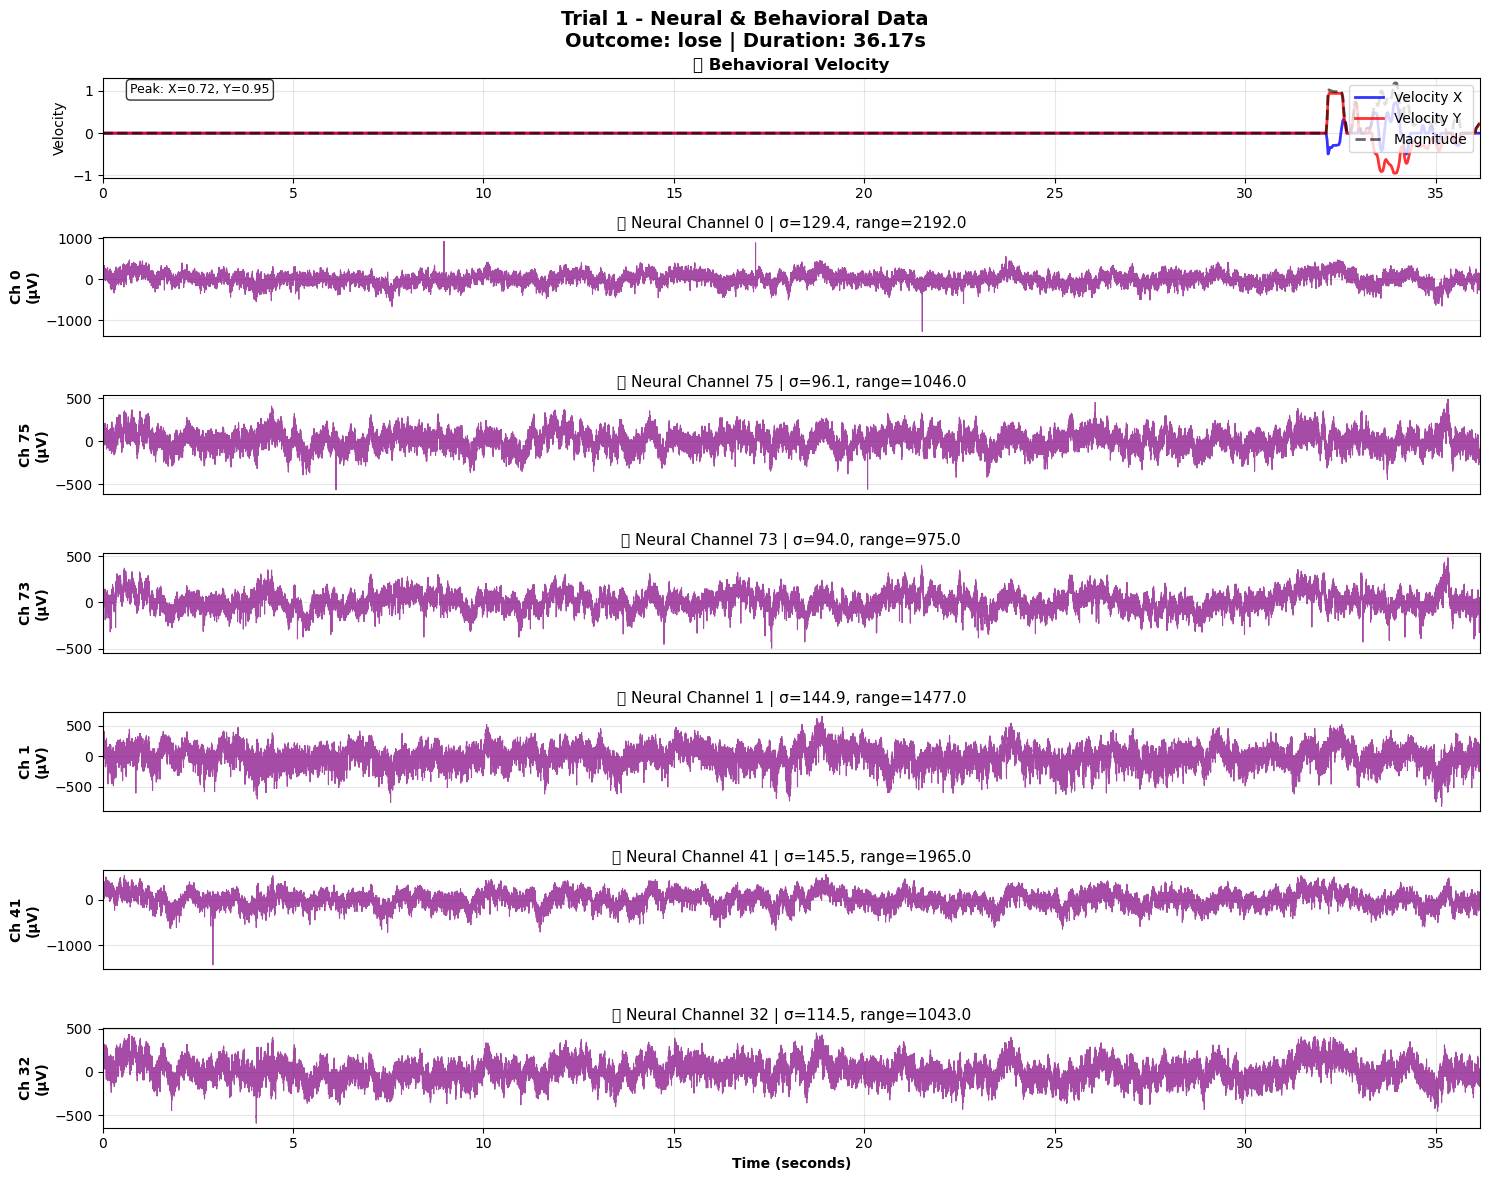


📊 Trial 1 Summary:
   Neural data: 96 channels, 1090964 samples
   Behavioral data: 1407 samples
   Velocity peaks: X=0.724, Y=0.945


In [5]:
# 1. Synchronized neural and behavioral visualization
if trial_data is not None and features is not None:
    plot_neural_behavioral_sync(
        trial_data=trial_data,
        features=features,
        spike_channels=SPIKE_CHANNELS,
        trial_number=TRIAL_NUMBER,
        figsize=(15, 12)
    )


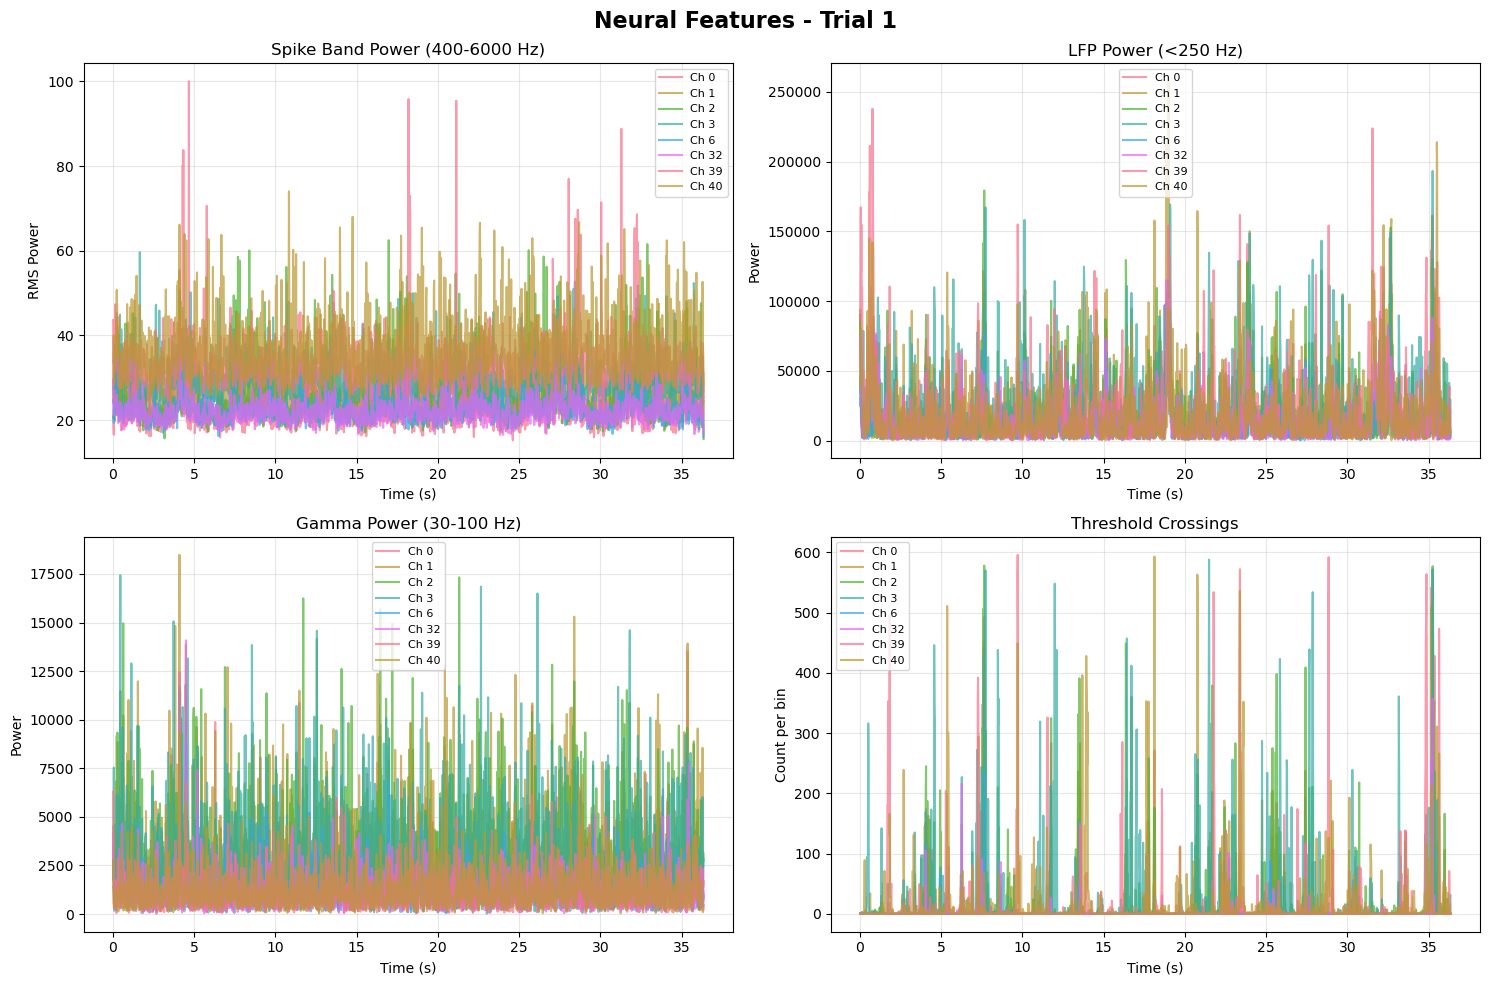

In [6]:
# 2. Feature overview plot
if features is not None:
    plot_feature_overview(
        features=features,
        spike_channels=SPIKE_CHANNELS,
        trial_number=TRIAL_NUMBER,
        n_channels=8,
        figsize=(15, 10)
    )


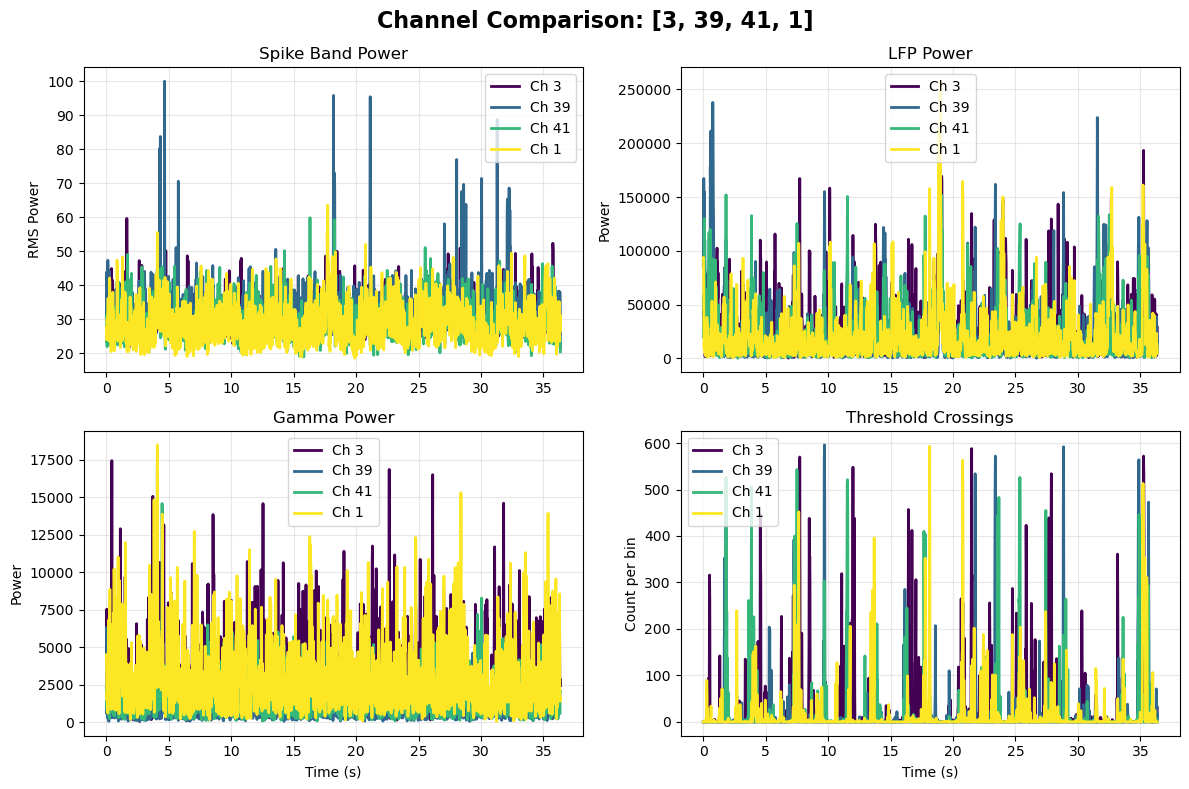

In [7]:
# 3. Compare most active channels
if features is not None and 'top_channels' in locals():
    # Take top 4 channels for comparison
    channels_to_compare = top_channels[:4]
    
    plot_channel_comparison(
        features=features,
        spike_channels=SPIKE_CHANNELS,
        channel_list=channels_to_compare,
        figsize=(12, 8)
    )


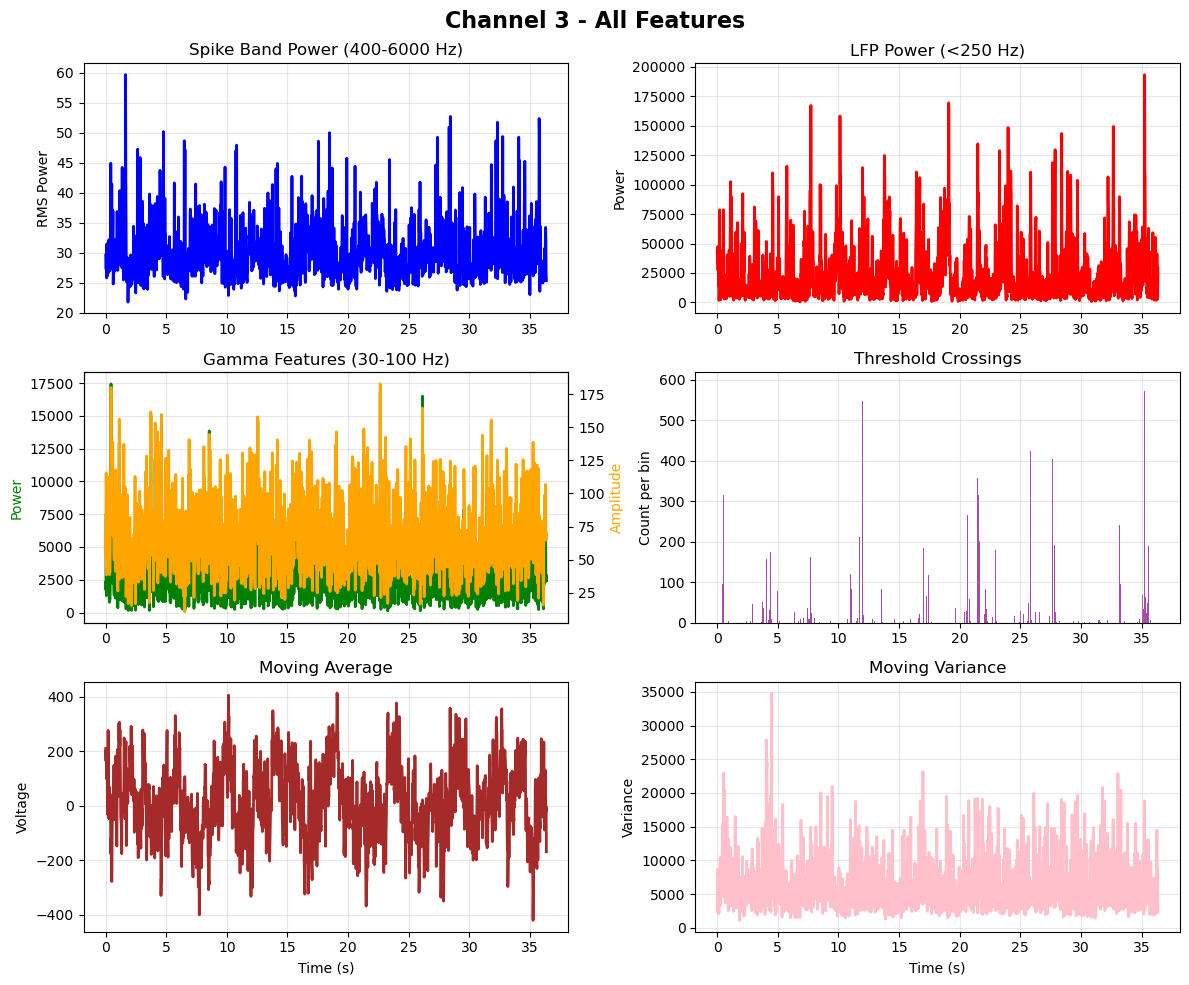


📊 Channel 3 Statistics:
  • Spike RMS Power: 29.922 ± 4.311
  • LFP Power: 23093.948 ± 24534.211
  • Gamma Power: 2937.115 ± 2262.881
  • Total Crossings: 38445
  • Moving Average: 13.117 ± 134.359
  • Moving Variance: 6141.825 ± 3741.183


In [8]:
# 4. Detailed analysis of the most active channel
if features is not None and 'top_channels' in locals():
    most_active_channel = top_channels[0]
    
    plot_channel_detail(
        features=features,
        spike_channels=SPIKE_CHANNELS,
        channel_number=most_active_channel,
        figsize=(12, 10)
    )


In [9]:
# Analyze behavioral correlation
if trial_data is not None and features is not None:
    correlation_results = analyze_behavioral_correlation(trial_data, features)
    
    print("🔗 NEURAL-BEHAVIORAL CORRELATION ANALYSIS:")
    print("=" * 50)
    
    if correlation_results['success']:
        print(f"✅ Correlation coefficient: {correlation_results['correlation']:.3f}")
        print(f"   Neural activity peak: {correlation_results['neural_activity_peak']:.3f}")
        print(f"   Velocity peak: {correlation_results['velocity_peak']:.3f}")
        print(f"   Samples analyzed: {correlation_results['neural_samples']}")
    else:
        print("⚠️  Correlation analysis not possible (no movement data)")
    
    # Get detailed channel statistics
    channel_stats = analyzer.get_channel_statistics(features, channel_indices=None)
    print(f"\n📊 Detailed statistics available for {len(channel_stats)} channels")
    
    # Compare top channels
    if 'top_channels' in locals():
        comparison = analyzer.compare_channels(features, top_channels[:3])
        print(f"\n🏆 Channel comparison results:")
        if 'spike_band' in comparison['features']:
            most_active = comparison['features']['spike_band']['most_active_channel']
            print(f"   Most active channel (spike band): {most_active}")
        if 'threshold' in comparison['features']:
            most_crossings = comparison['features']['threshold']['most_active_channel']
            print(f"   Most active channel (crossings): {most_crossings}")


🔗 NEURAL-BEHAVIORAL CORRELATION ANALYSIS:
✅ Correlation coefficient: 0.100
   Neural activity peak: 35.706
   Velocity peak: 1.191
   Samples analyzed: 1407

📊 Detailed statistics available for 21 channels

🏆 Channel comparison results:
   Most active channel (spike band): 39
   Most active channel (crossings): 3


🔍 INTERACTIVE EXPLORATION PARAMETERS:
   Trial: 2
   Channels for comparison: [0, 1, 2, 3]
   Channel for detailed analysis: 0
   Available trials with movement: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

🔍 Quick analysis of trial 2:
📁 Using H5 file: D:\Data\ScienceCorp\trials_aligned.h5
📂 Loading trial 2...
🔍 Extracting features for 21 channels...
🚀 Extracting features for 21 channels...
📊 Data shape: (21, 87168)
⏱️  Time bin size: 50 ms
🔍 Extracting spike band power (400-6000 Hz)...
✅ Spike band power extraction completed
🧠 Extracting LFP features (low-pass <250 Hz, gamma 30-100 Hz)...
✅ LFP feature extraction completed
⚡ Extracting voltage features (moving average and variance)...
✅ Voltage feature extraction completed
🎯 Extracting threshold crossings (-4x RMS)...
✅ Threshold crossing extraction completed
✅ Feature extraction complete!


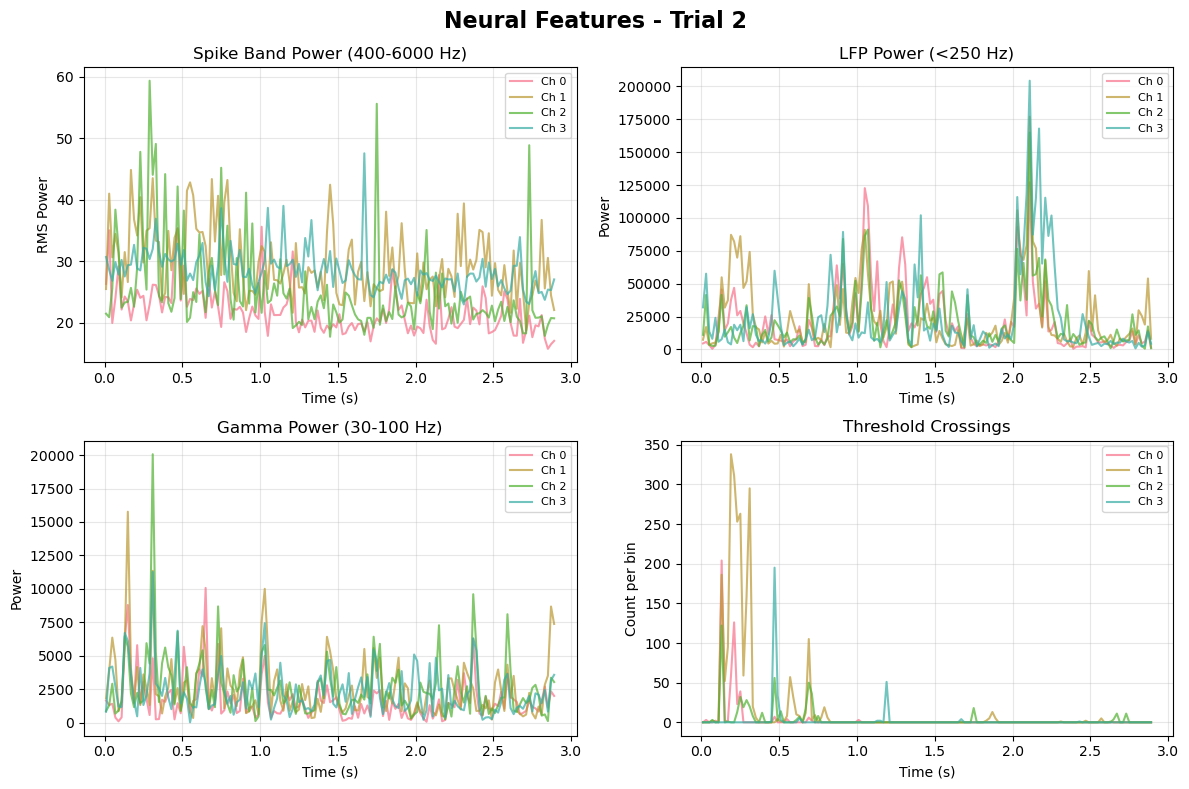

⭐ Trial 2 quality: EXCELLENT (score: 110.0/100)


In [13]:
# =============================================================================
# INTERACTIVE EXPLORATION SECTION
# =============================================================================

# Change these parameters to explore different aspects:
EXPLORE_TRIAL = 2  # Try different trials from the movement_trials list
EXPLORE_CHANNELS = [0, 1, 2, 3]  # Try different channel combinations
EXPLORE_CHANNEL_DETAIL = 0  # Single channel for detailed analysis

print("🔍 INTERACTIVE EXPLORATION PARAMETERS:")
print(f"   Trial: {EXPLORE_TRIAL}")
print(f"   Channels for comparison: {EXPLORE_CHANNELS}")
print(f"   Channel for detailed analysis: {EXPLORE_CHANNEL_DETAIL}")
print(f"   Available trials with movement: {movement_trials[:10] if 'movement_trials' in locals() else 'Run diagnostics first'}")

# Quick analysis of a different trial
if EXPLORE_TRIAL != TRIAL_NUMBER:
    print(f"\n🔍 Quick analysis of trial {EXPLORE_TRIAL}:")
    
    # Load and extract features for exploration trial
    explore_trial_data, explore_features = analyzer.load_and_extract_features(
        trial_number=EXPLORE_TRIAL,
        time_bin_size=TIME_BIN_SIZE,
        sampling_rate=SAMPLING_RATE
    )
    
    if explore_features is not None:
        # Quick feature overview
        plot_feature_overview(
            features=explore_features,
            spike_channels=SPIKE_CHANNELS,
            trial_number=EXPLORE_TRIAL,
            n_channels=4,
            figsize=(12, 8)
        )
        
        # Quality assessment
        explore_quality = get_trial_quality_score(explore_trial_data, explore_features)
        print(f"⭐ Trial {EXPLORE_TRIAL} quality: {explore_quality['assessment'].upper()} (score: {explore_quality['overall_score']:.1f}/100)")
else:
    print(f"\n💡 To explore a different trial, change EXPLORE_TRIAL to one of: {movement_trials[:5] if 'movement_trials' in locals() else 'Run diagnostics first'}")
